# Préprocessing et Modélisation
**Objectif :** Construire des pipelines d'apprentissage automatique, comparer différentes configurations de variables (Blocs A, B, C+) et optimiser le meilleur modèle (Forêt Aléatoire).

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [6]:
# Chargement et nettoyage
DATA_PATH = '../data/UNICEF-CME_DF_2021_WQ-1.0-download (1).csv'
df = pd.read_csv(DATA_PATH)

rename_map = {'Unit of measure': 'UNIT_MEASURE', 'Series Name': 'SERIES_NAME', 'Series Year': 'SERIES_YEAR'}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})
df = df.loc[:, ~df.columns.duplicated()]

for c in ['REF_DATE', 'SERIES_YEAR', 'LOWER_BOUND', 'UPPER_BOUND', 'OBS_VALUE']:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')
        
df_clean = df.drop_duplicates().copy()

# Feature Engineering : Décennie
df_clean['REF_DECADE'] = (df_clean['REF_DATE'] // 10) * 10
print(f"Pipeline de données prêt : {len(df_clean)} lignes.")

Pipeline de données prêt : 2400 lignes.


In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# 1. Définition de la cible
TARGET = 'OBS_VALUE'

# 2. Définition des blocs (A, B, C+)
features_A = ['Indicator', 'SEX', 'REF_DATE', 'UNIT_MEASURE', 'SERIES_NAME', 'LOWER_BOUND', 'UPPER_BOUND']
features_B = ['Indicator', 'SEX', 'REF_DATE', 'UNIT_MEASURE', 'SERIES_NAME']
features_C_plus = ['Indicator', 'SEX', 'REF_DATE', 'UNIT_MEASURE', 'SERIES_NAME', 'OBS_STATUS', 'SERIES_YEAR', 'TIME_PERIOD', 'INTERVAL', 'REF_DECADE']

# 3. Les modèles que l'on veut tester
model_specs = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42),
}

numeric_candidates = {'REF_DATE', 'SERIES_YEAR', 'LOWER_BOUND', 'UPPER_BOUND', 'REF_DECADE'}

# 4. LA FAMEUSE FONCTION MANQUANTE
def train_and_evaluate_block(df_input, features, block_name):
    d = df_input[features + [TARGET]].dropna(subset=[TARGET]).copy()
    if 'REF_DATE' in d.columns: 
        d = d.dropna(subset=['REF_DATE']).sort_values('REF_DATE')

    X = d[features]
    y = d[TARGET]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    num_feat = [f for f in features if f in numeric_candidates]
    cat_feat = [f for f in features if f not in numeric_candidates]

    pre = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_feat),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('oh', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))]), cat_feat),
    ], remainder='drop')

    rows = []
    best = {'name': None, 'rmse': float('inf'), 'r2': None}
    
    for name, reg in model_specs.items():
        pipe = Pipeline([('preprocess', pre), ('regressor', reg)])
        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)
        
        rmse = float(np.sqrt(mean_squared_error(y_test, pred)))
        r2 = float(r2_score(y_test, pred))
        
        rows.append({'Bloc': block_name, 'Modele': name, 'RMSE': rmse, 'R2': r2})
        if rmse < best['rmse']: 
            best = {'name': name, 'rmse': rmse, 'r2': r2}

    return pd.DataFrame(rows), best

--- ENTRAÎNEMENT ET COMPARAISON (A / B / C+) ---


,Bloc,Meilleur modele,RMSE,R2
0,A: Fuite d'info,Linear Regression,3.898272,0.999904
2,C+: Étendue,Random Forest,134.227876,0.885872
1,B: Base,Random Forest,136.458829,0.882047


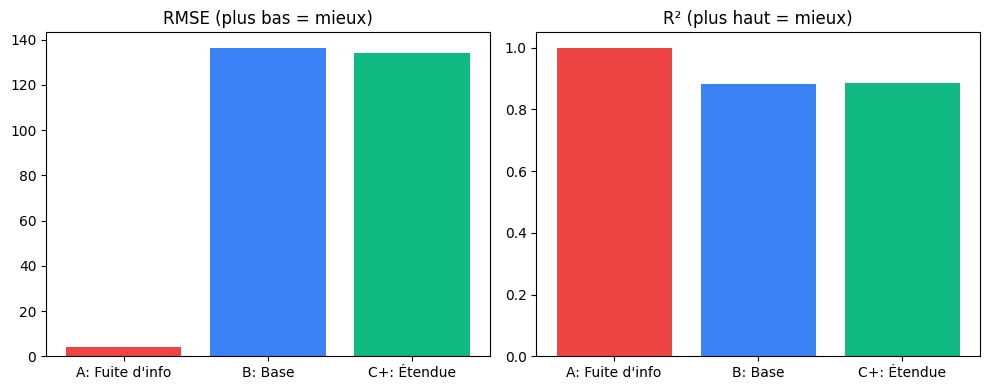

In [13]:
import warnings
warnings.filterwarnings('ignore')

print("--- ENTRAÎNEMENT ET COMPARAISON (A / B / C+) ---")
res_A, best_A = train_and_evaluate_block(df_clean, features_A, "A: Fuite d'information")
res_B, best_B = train_and_evaluate_block(df_clean, features_B, "B: Configuration de base")
res_C, best_C = train_and_evaluate_block(df_clean, features_C_plus, "C+: Configuration étendue")

summary = pd.DataFrame([
    {'Bloc': "A: Fuite d'info", 'Meilleur modele': best_A['name'], 'RMSE': best_A['rmse'], 'R2': best_A['r2']},
    {'Bloc': 'B: Base', 'Meilleur modele': best_B['name'], 'RMSE': best_B['rmse'], 'R2': best_B['r2']},
    {'Bloc': 'C+: Étendue', 'Meilleur modele': best_C['name'], 'RMSE': best_C['rmse'], 'R2': best_C['r2']},
])
display(summary.sort_values('RMSE'))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(summary['Bloc'], summary['RMSE'], color=['#ef4444', '#3b82f6', '#10b981'])
axes[0].set_title('RMSE (plus bas = mieux)')
axes[1].bar(summary['Bloc'], summary['R2'], color=['#ef4444', '#3b82f6', '#10b981'])
axes[1].set_title('R² (plus haut = mieux)')
plt.tight_layout()
plt.show()


--- COMPARAISON DES ALGORITHMES (Sur la configuration finale C+) ---


,Modele,RMSE,R2
0,Random Forest,134.227876,0.885872
1,Decision Tree,143.333337,0.869863
2,Linear Regression,2640.294244,-43.158215


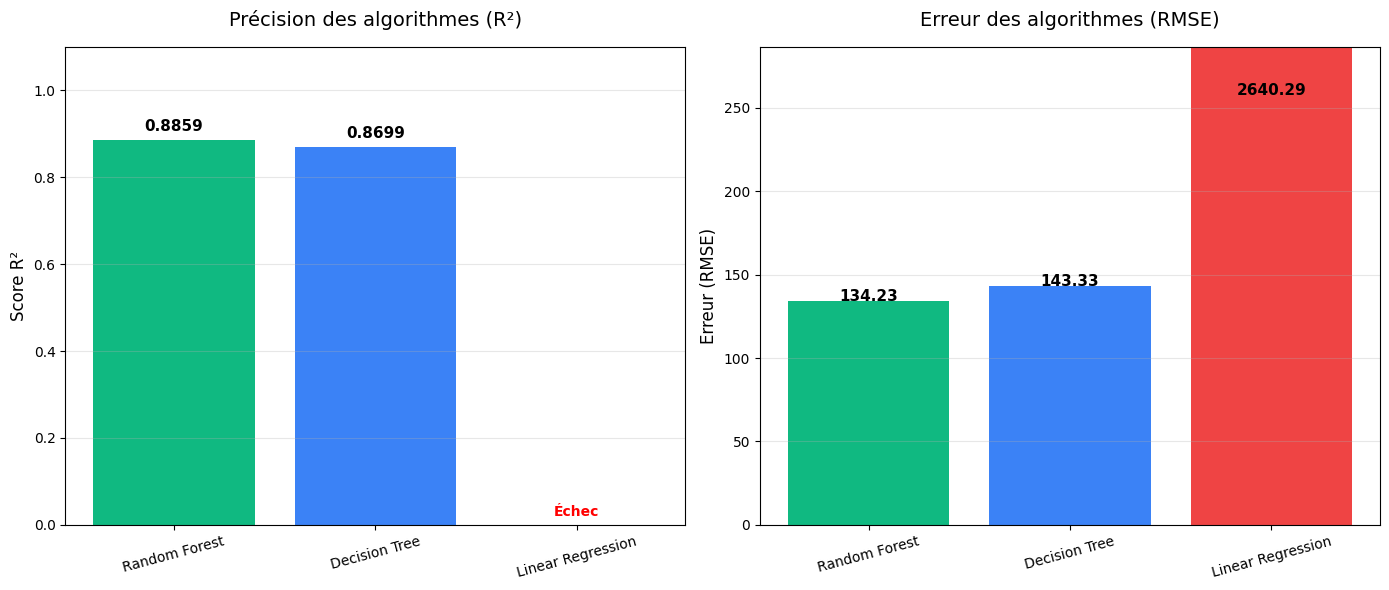

In [ ]:
print("\n--- COMPARAISON DES ALGORITHMES (Sur la configuration finale) ---")

# res_C contient déjà les performances, on trie
df_models = res_C.sort_values(by='R2', ascending=False).reset_index(drop=True)
display(df_models[['Modele', 'RMSE', 'R2']])

# 1. Ajustement de la taille (Plus large, moins haut) et de la résolution
fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=100)

colors = ['#10b981', '#3b82f6', '#ef4444']

# --- Graphique 1 : R² ---
axes[0].bar(df_models['Modele'], df_models['R2'], color=colors)
axes[0].set_title('Précision des algorithmes (R²)', pad=15, fontsize=14)
axes[0].set_ylabel('Score R²', fontsize=12)
# On force l'affichage entre 0 et 1.1 (même si LinReg est dans le négatif)
axes[0].set_ylim(0, 1.1) 
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=15) # Incline les noms des modèles

for i, v in enumerate(df_models['R2']):
    # N'affiche le texte que si la valeur est supérieure à 0
    if v > 0:
        axes[0].text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold', fontsize=11)
    else:
        axes[0].text(i, 0.02, "Échec", ha='center', fontweight='bold', color='red')

# --- Graphique 2 : RMSE ---
axes[1].bar(df_models['Modele'], df_models['RMSE'], color=colors)
axes[1].set_title('Erreur des algorithmes (RMSE)', pad=15, fontsize=14)
axes[1].set_ylabel('Erreur (RMSE)', fontsize=12)

# 2. SOLUTION POUR NE PAS ÉTIRER LA PAGE :
# On cherche le pire RMSE parmi les "bons" modèles (Random Forest ou Decision Tree)
# pour plafonner l'axe et ne pas laisser la Régression Linéaire tout écraser.
max_normal_rmse = df_models.loc[df_models['Modele'] != 'Linear Regression', 'RMSE'].max()
axes[1].set_ylim(0, max_normal_rmse * 2) # On coupe la barre rouge au double des autres

axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=15) # Incline les noms des modèles

for i, v in enumerate(df_models['RMSE']):
    # Si la valeur crève le plafond, on l'écrit tout en haut
    y_pos = min(v + 0.05, max_normal_rmse * 1.8)
    axes[1].text(i, y_pos, f"{v:.2f}", ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

In [9]:
print("--- OPTIMISATION DU MODÈLE FINAL (Random Forest) ---")
pipe_rf = Pipeline([
    ('preprocess', preprocessor), 
    ('regressor', RandomForestRegressor(random_state=42))
])

# Grille de recherche d'hyperparamètres
param_grid = {
    'regressor__n_estimators': [80, 120, 150],
    'regressor__max_depth': [10, 15, 20]
}

grid = GridSearchCV(pipe_rf, param_grid, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
pred = best_model.predict(X_test)

rmse = float(np.sqrt(mean_squared_error(y_test, pred)))
r2 = float(r2_score(y_test, pred))

print(f"Meilleurs hyperparamètres : {grid.best_params_}")
print(f"Performances finales -> RMSE : {rmse:.4f} | R² : {r2:.4f}")

--- OPTIMISATION DU MODÈLE FINAL (Random Forest) ---
Meilleurs hyperparamètres : {'regressor__max_depth': 20, 'regressor__n_estimators': 120}
Performances finales -> RMSE : 133.9862 | R² : 0.8863


c:\Users\moham\Documents\ml project s2\django_infant_mortality\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


--- ANALYSE DES RÉSIDUS ---


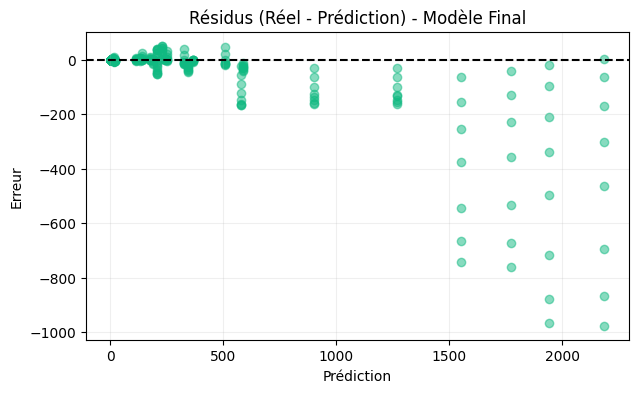

In [10]:
print("--- ANALYSE DES RÉSIDUS ---")
plt.figure(figsize=(7, 4))
plt.scatter(pred, y_test.values - pred, alpha=0.5, color='#10b981')
plt.axhline(0, color='black', linestyle='--')
plt.title('Résidus (Réel - Prédiction) - Modèle Final')
plt.xlabel('Prédiction')
plt.ylabel('Erreur')
plt.grid(alpha=0.2)
plt.show()